## Notebook Overview
## Remove ISUP 0, Binary Classification
- This notebook evaluates multiple machine‑learning classifiers on a binary prostate cancer prediction task after removing ISUP 0 and balancing the remaining classes using SMOTE (k=3). 
-  The goal is to assess how well different models can distinguish ISUP 1 from ISUP ≥2 under a fully balanced training distribution, where ISUP grade 1 is assigned to class 0 (clinically insignificant cancer) and ISUP grades 2-5 are assigned (clinically significant cancer).
- The workflow applies nested cross‑validation with hyperparameter tuning and reports performance using accuracy, ROC‑AUC, confusion matrices and entropy‑based uncertainty.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone

from scipy.stats import entropy
from tqdm import tqdm
from IPython.display import display

from deep_gp.preprocessing_data import load_data

In [3]:
# Load original data
data = load_data()

# Remove class 0 entirely
df_filtered = data[data["case_ISUP"] != 0].copy()

# Create binary target: 1 if ISUP >= 2, else 0
df_filtered["binary_target"] = (df_filtered["case_ISUP"] >= 2).astype(int)
# Features and target before SMOTE
X_filtered = df_filtered.drop(columns=["case_ISUP", "binary_target"])
y_filtered = df_filtered["binary_target"]

print("Before SMOTE:")
print(y_filtered.value_counts().sort_index())

# Apply SMOTE to balance class 0 (ISUP 1)
sm = SMOTE(k_neighbors=3,random_state=42)
X_smote, y_smote = sm.fit_resample(X_filtered, y_filtered)

print("\nAfter SMOTE:")
print(y_smote.value_counts().sort_index())


Before SMOTE:
binary_target
0    157
1    285
Name: count, dtype: int64

After SMOTE:
binary_target
0    285
1    285
Name: count, dtype: int64


In [3]:
# Model evaluation function

def evaluate_models_cv_with_tuning(X, y, label):

    print(f"\n=== Feature set: {label} ===")

    # Base models (unfitted templates)
    base_models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="saga",
                max_iter=30000,
                tol=1e-4
            ))
        ]),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),

        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),

        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                tree_method="hist",
                eval_metric="logloss",
                random_state=42
            ))
        ]),

        "Gaussian Process": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GaussianProcessClassifier(
                kernel=C(1.0, (1e-6, 1e6)) *
                       RBF(length_scale=1.0, length_scale_bounds=(1e-6, 1e6)) +
                       WhiteKernel(noise_level=1e-3),
                n_restarts_optimizer=2,
                random_state=42
            ))
        ])
    }

    # Hyperparameter grids
    param_grids = {
        "Logistic Regression": {
            "clf__C": [0.01, 0.1, 1.0]
        },
        "KNN": {
            "clf__n_neighbors": [3, 5, 7, 9],
            "clf__weights": ["uniform", "distance"]
        },
        "Random Forest": {
            "clf__n_estimators": [100, 200, 300, 400, 500],
            "clf__max_depth": [None, 5, 10, 20],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 4],
            "clf__max_features": ["sqrt", "log2", None]
        },
        "XGBoost": {
            "clf__n_estimators": [100, 200, 300, 400],
            "clf__learning_rate": [0.01, 0.05, 0.1, 0.3],
            "clf__max_depth": [3, 4, 5, 6],
            "clf__subsample": [0.7, 0.8, 0.9, 1.0],
            "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        },
        "Gaussian Process": {
            "clf__kernel": [
                C(c, (1e-6, 1e6)) * RBF(length_scale=l, length_scale_bounds=(1e-6, 1e6)) +
                WhiteKernel(noise_level=1e-3)
                for c in [0.5, 1.0, 2.0]
                for l in [0.5, 1.0, 2.0]
            ] + [RBF(1.0)],
            "clf__n_restarts_optimizer": [0, 2]
        }
    }

    # Outer CV
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    for model_name, base_model in base_models.items():
        print(f"\n=== Evaluation: {model_name} ===")

        y_pred_all = np.zeros(len(y))
        y_prob_all = np.zeros(len(y))
        uncertainty_all = np.zeros(len(y))

        best_params_last_fold = None  # store best params

        for train_idx, test_idx in tqdm(
            skf_outer.split(X, y),
            total=skf_outer.get_n_splits(),
            desc=f"Outer CV ({model_name})"
        ):
           
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            model_clone = clone(base_model)

            if model_name in ["Random Forest", "XGBoost"]:
                tuner = RandomizedSearchCV(
                    model_clone,
                    param_distributions=param_grids[model_name],
                    n_iter=20,
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1,
                    random_state=42
                )
            else:
                tuner = GridSearchCV(
                    model_clone,
                    param_grid=param_grids[model_name],
                    cv=cv_inner,
                    scoring="roc_auc",
                    n_jobs=-1
                )

            tuner.fit(X_train, y_train)
            best_model = tuner.best_estimator_
            best_params_last_fold = tuner.best_params_

            # Refit on full outer-train
            best_model.fit(X_train, y_train)

            y_prob = best_model.predict_proba(X_test)[:, 1]
            y_pred = best_model.predict(X_test)

            # Entropy-based uncertainty (per sample)
            probs = np.vstack([y_prob, 1 - y_prob])
            uncertainty = entropy(probs, base=2, axis=0)

            y_pred_all[test_idx] = y_pred
            y_prob_all[test_idx] = y_prob
            uncertainty_all[test_idx] = uncertainty

        # After all folds 
        print("\n>>> Best hyperparameters (last outer fold):", best_params_last_fold)
        print("Accuracy:", accuracy_score(y, y_pred_all))
        print("ROC-AUC:", roc_auc_score(y, y_prob_all))
        print("Mean uncertainty:", uncertainty_all.mean())
        print("Uncertainty (Pred=0):", uncertainty_all[y_pred_all == 0].mean())
        print("Uncertainty (Pred=1):", uncertainty_all[y_pred_all == 1].mean())
        print("Confusion matrix:\n", confusion_matrix(y, y_pred_all))
        print(classification_report(y, y_pred_all))

        # ROC curve for this model
        fpr, tpr, _ = roc_curve(y, y_prob_all)
        roc_auc_val = auc(fpr, tpr)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} — ROC Curve")
        plt.legend()
        plt.grid(True)
        plt.show()

        results[model_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "roc_auc": roc_auc_val,
            "accuracy": accuracy_score(y, y_pred_all),
            "mean_uncertainty": uncertainty_all.mean(),
            "uncertainty_0": uncertainty_all[y_pred_all == 0].mean(),
            "uncertainty_1": uncertainty_all[y_pred_all == 1].mean()
        }

    # SUMMARY TABLE
    summary_df = pd.DataFrame([
        {
            "Model": name,
            "Accuracy": m["accuracy"],
            "ROC-AUC": m["roc_auc"],
            "Mean Uncertainty": m["mean_uncertainty"],
            "Uncertainty (Pred=0)": m["uncertainty_0"],
            "Uncertainty (Pred=1)": m["uncertainty_1"]
        }
        for name, m in results.items()
    ])

    print("\n=== Summary Table ===")
    display(summary_df)

    # Combined ROC plot
    plt.figure(figsize=(8, 6))
    for model_name, m in results.items():
        plt.plot(m["fpr"], m["tpr"], lw=2,
                 label=f'{model_name} (AUC = {m["roc_auc"]:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — {label}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()





=== Feature set: ISUP 1–5 (SMOTE applied) ===

=== Evaluation: Logistic Regression ===


Outer CV (Logistic Regression): 100%|██████████| 5/5 [00:09<00:00,  1.97s/it]


>>> Best hyperparameters (last outer fold): {'clf__C': 0.01}
Accuracy: 0.5543859649122806
ROC-AUC: 0.5794644506001847
Mean uncertainty: 0.9534091167608411
Uncertainty (Pred=0): 0.9579305023745042
Uncertainty (Pred=1): 0.9479025264998429
Confusion matrix:
 [[172 113]
 [141 144]]
              precision    recall  f1-score   support

           0       0.55      0.60      0.58       285
           1       0.56      0.51      0.53       285

    accuracy                           0.55       570
   macro avg       0.55      0.55      0.55       570
weighted avg       0.55      0.55      0.55       570



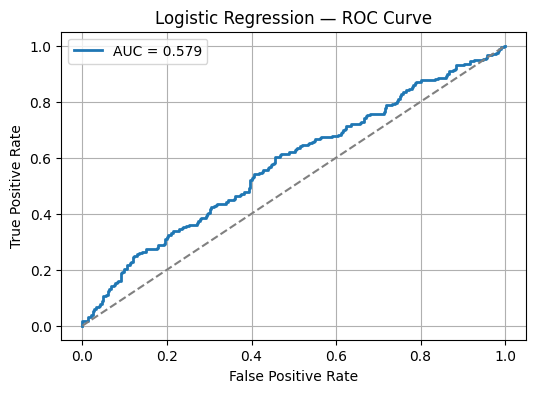


=== Evaluation: KNN ===


Outer CV (KNN): 100%|██████████| 5/5 [00:01<00:00,  2.87it/s]


>>> Best hyperparameters (last outer fold): {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Accuracy: 0.6140350877192983
ROC-AUC: 0.701372730070791
Mean uncertainty: 0.549194821319837
Uncertainty (Pred=0): 0.5089331782433295
Uncertainty (Pred=1): 0.6266210580054286
Confusion matrix:
 [[220  65]
 [155 130]]
              precision    recall  f1-score   support

           0       0.59      0.77      0.67       285
           1       0.67      0.46      0.54       285

    accuracy                           0.61       570
   macro avg       0.63      0.61      0.60       570
weighted avg       0.63      0.61      0.60       570



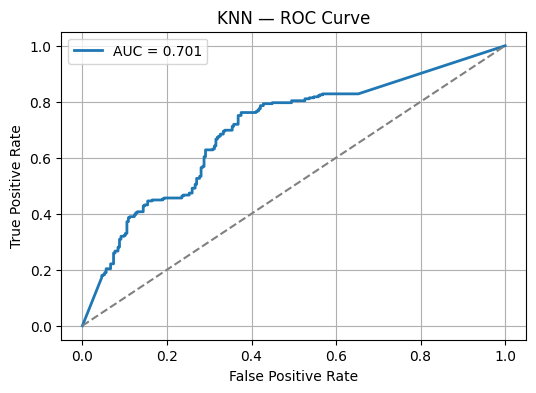


=== Evaluation: Random Forest ===


Outer CV (Random Forest): 100%|██████████| 5/5 [04:04<00:00, 48.90s/it]


>>> Best hyperparameters (last outer fold): {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Accuracy: 0.6877192982456141
ROC-AUC: 0.7422468451831332
Mean uncertainty: 0.9086477303669103
Uncertainty (Pred=0): 0.8870531514595426
Uncertainty (Pred=1): 0.9318128241039048
Confusion matrix:
 [[201  84]
 [ 94 191]]
              precision    recall  f1-score   support

           0       0.68      0.71      0.69       285
           1       0.69      0.67      0.68       285

    accuracy                           0.69       570
   macro avg       0.69      0.69      0.69       570
weighted avg       0.69      0.69      0.69       570



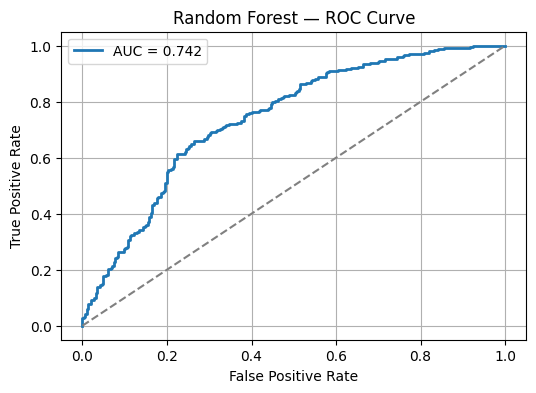


=== Evaluation: XGBoost ===


Outer CV (XGBoost): 100%|██████████| 5/5 [04:39<00:00, 55.98s/it]



>>> Best hyperparameters (last outer fold): {'clf__subsample': 0.8, 'clf__n_estimators': 400, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.9}
Accuracy: 0.7
ROC-AUC: 0.7488704216682055
Mean uncertainty: 0.6212621659661333
Uncertainty (Pred=0): 0.597236880684132
Uncertainty (Pred=1): 0.6468543176795694
Confusion matrix:
 [[204  81]
 [ 90 195]]
              precision    recall  f1-score   support

           0       0.69      0.72      0.70       285
           1       0.71      0.68      0.70       285

    accuracy                           0.70       570
   macro avg       0.70      0.70      0.70       570
weighted avg       0.70      0.70      0.70       570



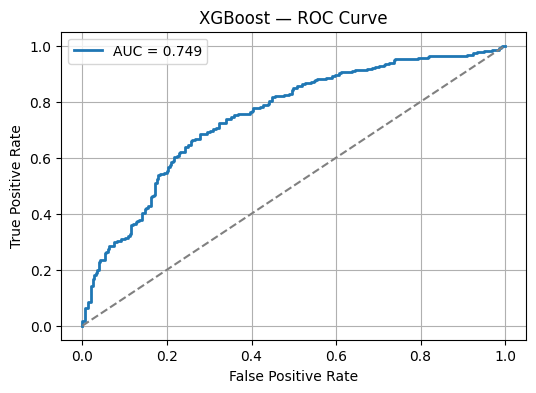


=== Evaluation: Gaussian Process ===


Outer CV (Gaussian Process):   0%|          | 0/5 [00:00<?, ?it/s]/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise


>>> Best hyperparameters (last outer fold): {'clf__kernel': 0.707**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.001), 'clf__n_restarts_optimizer': 0}
Accuracy: 0.6719298245614035
ROC-AUC: 0.73290243151739
Mean uncertainty: 0.9664053188754376
Uncertainty (Pred=0): 0.9532396496502781
Uncertainty (Pred=1): 0.9876636471656033
Confusion matrix:
 [[225  60]
 [127 158]]
              precision    recall  f1-score   support

           0       0.64      0.79      0.71       285
           1       0.72      0.55      0.63       285

    accuracy                           0.67       570
   macro avg       0.68      0.67      0.67       570
weighted avg       0.68      0.67      0.67       570



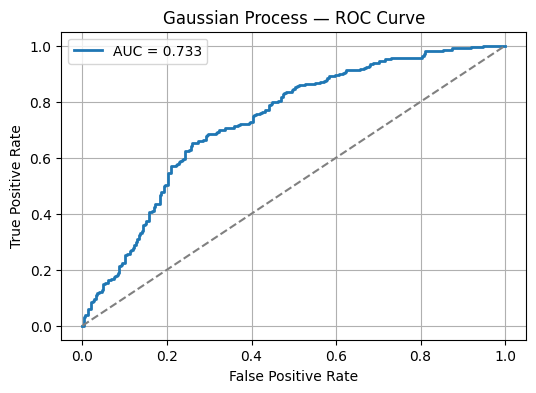


=== Summary Table ===


,Model,Accuracy,ROC-AUC,Mean Uncertainty,Uncertainty (Pred=0),Uncertainty (Pred=1)
0,Logistic Regression,0.554386,0.579464,0.953409,0.957931,0.947903
1,KNN,0.614035,0.701373,0.549195,0.508933,0.626621
2,Random Forest,0.687719,0.742247,0.908648,0.887053,0.931813
3,XGBoost,0.700000,0.748870,0.621262,0.597237,0.646854
4,Gaussian Process,0.671930,0.732902,0.966405,0.953240,0.987664


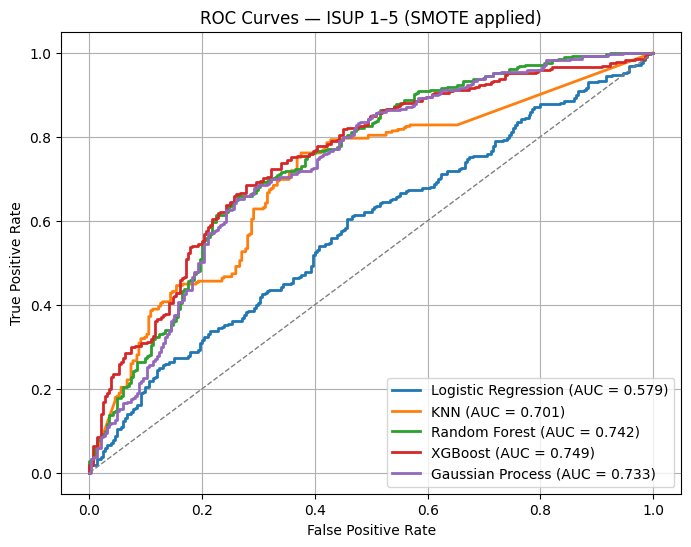

In [4]:
evaluate_models_cv_with_tuning(X_smote, y_smote, "ISUP 1–5 (SMOTE applied)")
